In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

project_root


WindowsPath('c:/Users/Thomas/Desktop/bearing-condition-monitor')

In [2]:
from bcmonitor.data_loader import load_raw_sample, describe_signal
from bcmonitor.plotting import (
    get_figures_dir,
    plot_raw_comparison,
    plot_fft_comparison,
    plot_signal_spectrogram,
)

figures_dir = get_figures_dir(project_root)
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

figures_dir, processed_dir


(WindowsPath('c:/Users/Thomas/Desktop/bearing-condition-monitor/reports/figures'),
 WindowsPath('c:/Users/Thomas/Desktop/bearing-condition-monitor/data/processed'))

## Representative raw-signal inspection

In [3]:
normal = load_raw_sample("normal_0.mat", sample_rate=12000.0)
inner = load_raw_sample("ir007_0.mat", sample_rate=12000.0)
ball = load_raw_sample("b007_0.mat", sample_rate=12000.0)
outer = load_raw_sample("or007_6_0.mat", sample_rate=12000.0)


In [4]:
import pandas as pd

signal_summary_df = pd.DataFrame([
    describe_signal(normal),
    describe_signal(inner),
    describe_signal(ball),
    describe_signal(outer),
])

signal_summary_df


,file_name,n_samples,sample_rate_hz,rpm,signal_key,rpm_key,mean,std,min,max
0,normal_0.mat,243938,12000.0,1796.0,X097_DE_time,X097RPM,0.012558,0.072687,-0.286638,0.311254
1,ir007_0.mat,121265,12000.0,1797.0,X105_DE_time,X105RPM,0.013444,0.291216,-1.379886,1.739030
2,b007_0.mat,122571,12000.0,1796.0,X118_DE_time,X118RPM,0.012607,0.138662,-0.607020,0.603934
3,or007_6_0.mat,121991,12000.0,1796.0,X130_DE_time,X130RPM,0.023171,0.669104,-3.408701,3.630425


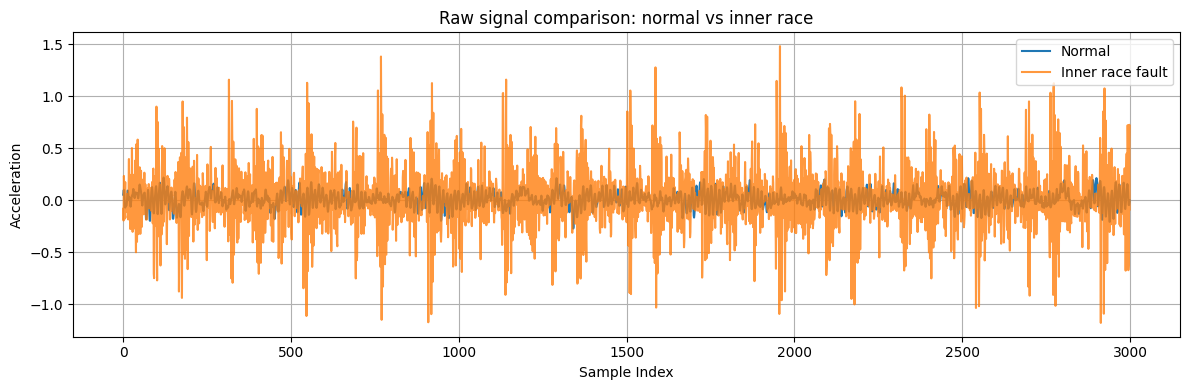

In [5]:
plot_raw_comparison(
    normal.signal,
    inner.signal,
    label_a="Normal",
    label_b="Inner race fault",
    title="Raw signal comparison: normal vs inner race",
    output_path=figures_dir / "raw_normal_vs_inner.png",
)


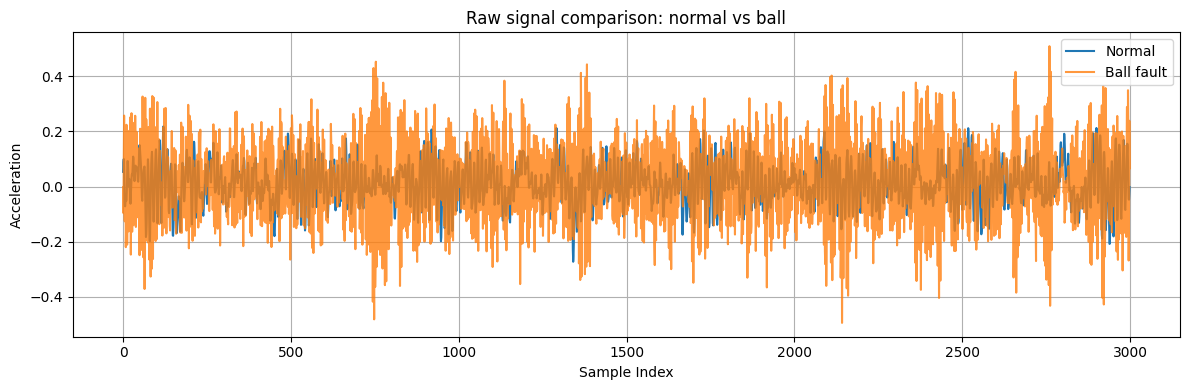

In [6]:
plot_raw_comparison(
    normal.signal,
    ball.signal,
    label_a="Normal",
    label_b="Ball fault",
    title="Raw signal comparison: normal vs ball",
    output_path=figures_dir / "raw_normal_vs_ball.png",
)


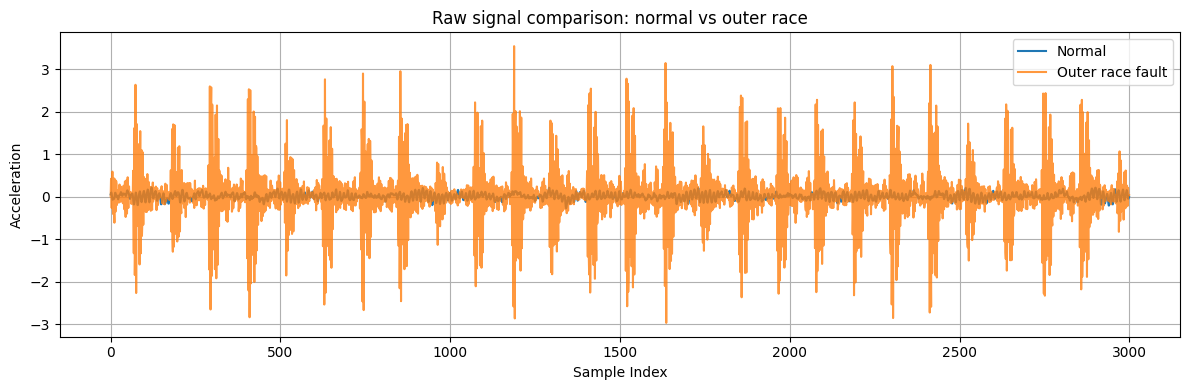

In [7]:
plot_raw_comparison(
    normal.signal,
    outer.signal,
    label_a="Normal",
    label_b="Outer race fault",
    title="Raw signal comparison: normal vs outer race",
    output_path=figures_dir / "raw_normal_vs_outer.png",
)


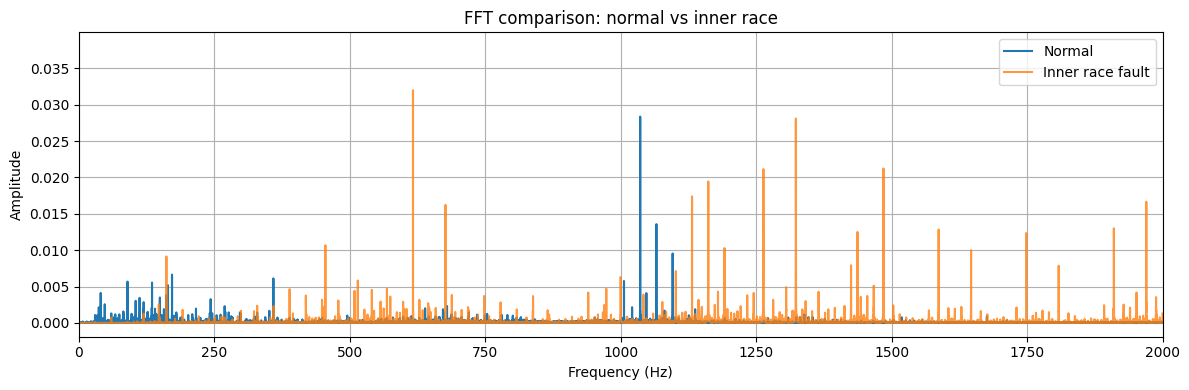

In [8]:
plot_fft_comparison(
    normal.signal,
    inner.signal,
    sample_rate=12000.0,
    label_a="Normal",
    label_b="Inner race fault",
    title="FFT comparison: normal vs inner race",
    output_path=figures_dir / "fft_normal_vs_inner.png",
)


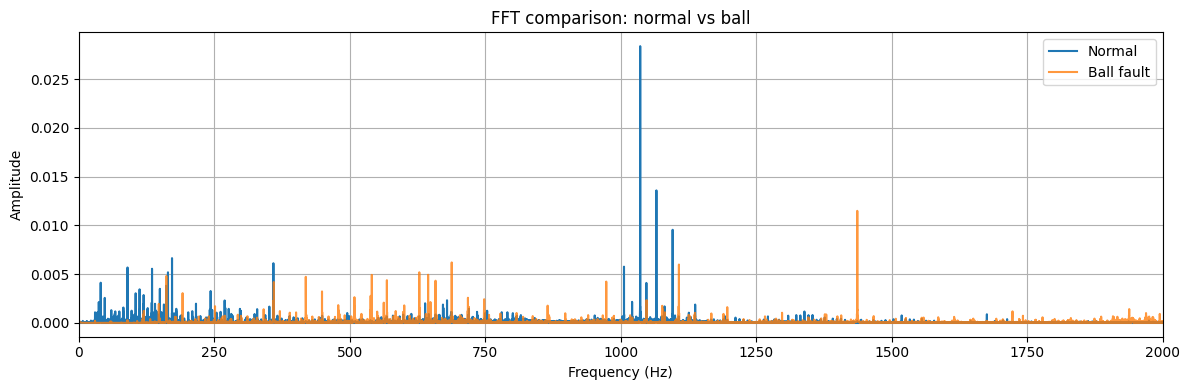

In [9]:
plot_fft_comparison(
    normal.signal,
    ball.signal,
    sample_rate=12000.0,
    label_a="Normal",
    label_b="Ball fault",
    title="FFT comparison: normal vs ball",
    output_path=figures_dir / "fft_normal_vs_ball.png",
)


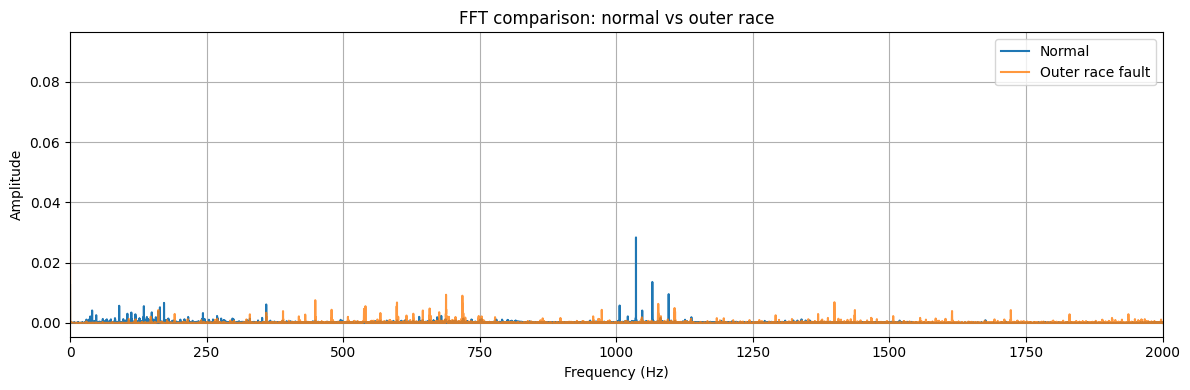

In [10]:
plot_fft_comparison(
    normal.signal,
    outer.signal,
    sample_rate=12000.0,
    label_a="Normal",
    label_b="Outer race fault",
    title="FFT comparison: normal vs outer race",
    output_path=figures_dir / "fft_normal_vs_outer.png",
)


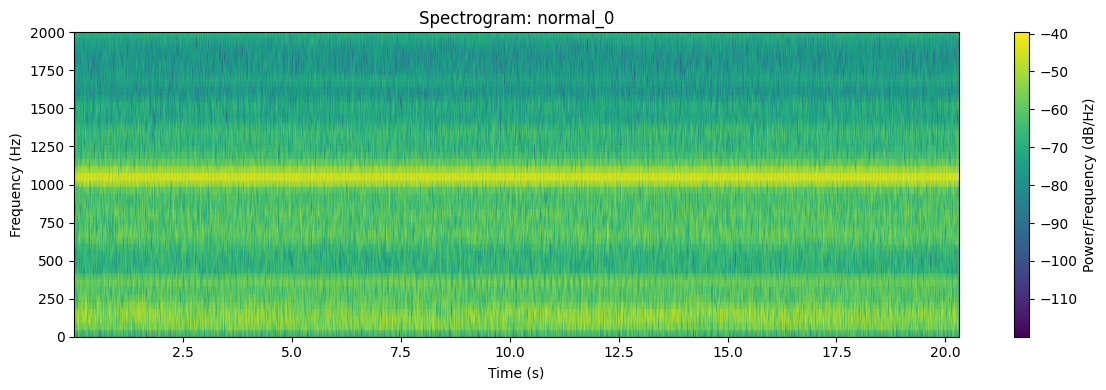

In [11]:
plot_signal_spectrogram(
    normal.signal,
    sample_rate=12000.0,
    title="Spectrogram: normal_0",
    output_path=figures_dir / "spectrogram_normal_0.png",
)


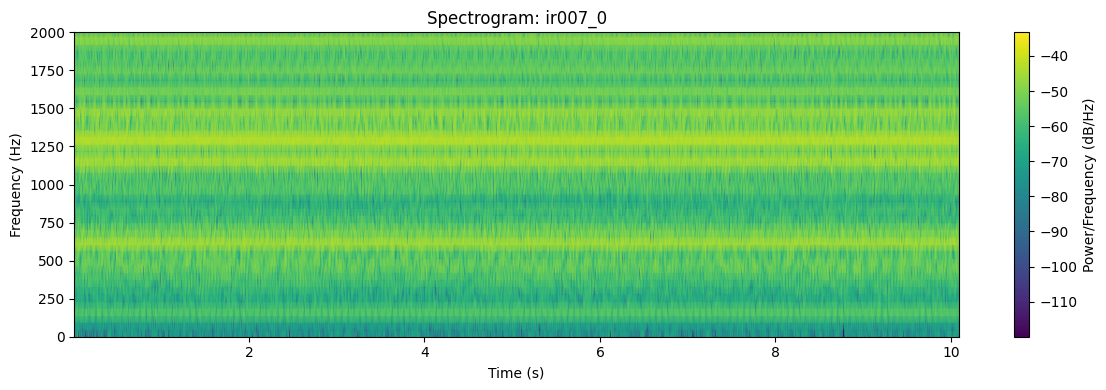

In [12]:
plot_signal_spectrogram(
    inner.signal,
    sample_rate=12000.0,
    title="Spectrogram: ir007_0",
    output_path=figures_dir / "spectrogram_ir007_0.png",
)


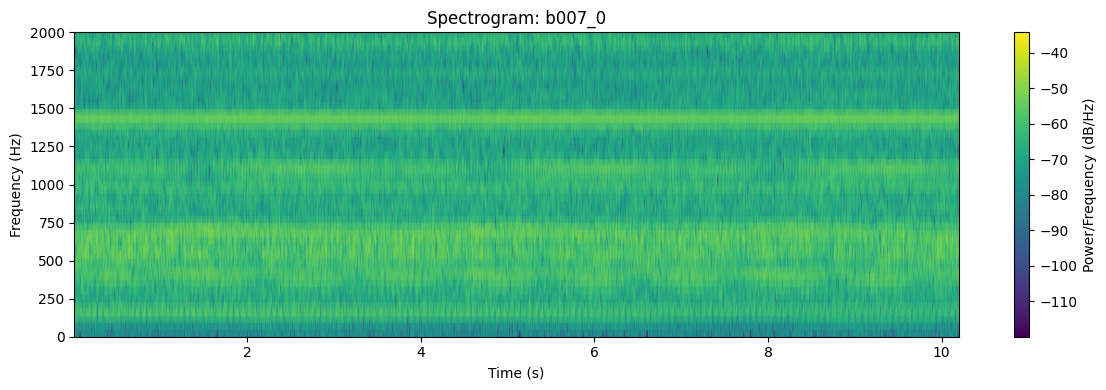

In [13]:
plot_signal_spectrogram(
    ball.signal,
    sample_rate=12000.0,
    title="Spectrogram: b007_0",
    output_path=figures_dir / "spectrogram_b007_0.png",
)


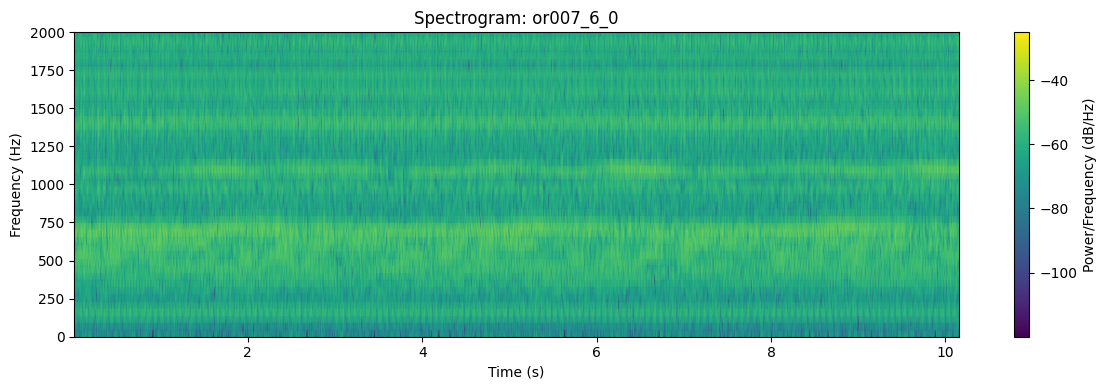

In [14]:
plot_signal_spectrogram(
    outer.signal,
    sample_rate=12000.0,
    title="Spectrogram: or007_6_0",
    output_path=figures_dir / "spectrogram_or007_6_0.png",
)


## Dataset validation and manifest inspection

In [15]:
from bcmonitor.datasets import (
    get_project_file_specs,
    validate_dataset_files,
    specs_to_dataframe,
)
from bcmonitor.features import build_feature_table, get_feature_columns

project_specs = get_project_file_specs()
validation = validate_dataset_files(project_specs)
validation


{'raw_dir': WindowsPath('C:/Users/Thomas/Desktop/bearing-condition-monitor/data/raw'),
 'expected_count': 40,
 'present_expected_count': 40,
 'missing_count': 0,
 'missing_files': [],
 'unexpected_count': 0,
 'unexpected_files': [],
 'all_present': True}

In [16]:
if not validation["all_present"]:
    raise FileNotFoundError(
        f"Cannot run the full Version 2 notebook. "
        f"{validation['missing_count']} raw files are missing: {validation['missing_files']}"
    )


In [17]:
specs_df = specs_to_dataframe(project_specs)
specs_df.head()


,file_name,label,health_state,fault_type,fault_size_in,load_id,sensor_location,sample_rate_hz,outer_race_position
0,normal_0.mat,normal,normal,None,NaN,0,drive_end,12000.0,None
1,normal_1.mat,normal,normal,None,NaN,1,drive_end,12000.0,None
2,normal_2.mat,normal,normal,None,NaN,2,drive_end,12000.0,None
3,normal_3.mat,normal,normal,None,NaN,3,drive_end,12000.0,None
4,ir007_0.mat,inner_race,fault,inner_race,0.007,0,drive_end,12000.0,None


In [18]:
specs_df.groupby(["label", "fault_size_in"], dropna=False).size().rename("file_count").reset_index()


,label,fault_size_in,file_count
0,ball,0.007,4
1,ball,0.014,4
2,ball,0.021,4
3,inner_race,0.007,4
4,inner_race,0.014,4
5,inner_race,0.021,4
6,normal,NaN,4
7,outer_race,0.007,4
8,outer_race,0.014,4
9,outer_race,0.021,4


## Feature extraction

In [19]:
feature_table_baseline = build_feature_table(
    project_specs,
    sample_rate=12000.0,
    window_size=2048,
    step_size=1024,
    feature_set="baseline",
)

feature_table_enhanced = build_feature_table(
    project_specs,
    sample_rate=12000.0,
    window_size=2048,
    step_size=1024,
    feature_set="enhanced",
)

feature_table_baseline.shape, feature_table_enhanced.shape


c:\Users\Thomas\Desktop\bearing-condition-monitor\src\bcmonitor\features.py:308: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(tables, ignore_index=True)


((5886, 20), (5886, 26))

In [20]:
len(get_feature_columns("baseline")), len(get_feature_columns("enhanced"))


(11, 17)

In [21]:
feature_table_baseline.to_csv(processed_dir / "feature_table_baseline.csv", index=False)
feature_table_enhanced.to_csv(processed_dir / "feature_table_enhanced.csv", index=False)

sorted([p.name for p in processed_dir.glob("feature_table*.csv")])


['feature_table.csv',
 'feature_table_16files.csv',
 'feature_table_16files_balanced.csv',
 'feature_table_4files.csv',
 'feature_table_baseline.csv',
 'feature_table_baseline_balanced.csv',
 'feature_table_enhanced.csv',
 'feature_table_enhanced_balanced.csv']

In [22]:
feature_table_baseline["label"].value_counts(), feature_table_enhanced["label"].value_counts()


(label
 normal        1652
 outer_race    1413
 ball          1411
 inner_race    1410
 Name: count, dtype: int64,
 label
 normal        1652
 outer_race    1413
 ball          1411
 inner_race    1410
 Name: count, dtype: int64)

In [23]:
file_counts_baseline = feature_table_baseline["source_file"].value_counts().sort_index()
min_windows_per_file_baseline = int(file_counts_baseline.min())

file_counts_enhanced = feature_table_enhanced["source_file"].value_counts().sort_index()
min_windows_per_file_enhanced = int(file_counts_enhanced.min())

balanced_feature_table_baseline = (
    feature_table_baseline
    .groupby("source_file", group_keys=False)
    .sample(n=min_windows_per_file_baseline, random_state=42)
    .reset_index(drop=True)
)

balanced_feature_table_enhanced = (
    feature_table_enhanced
    .groupby("source_file", group_keys=False)
    .sample(n=min_windows_per_file_enhanced, random_state=42)
    .reset_index(drop=True)
)

balanced_feature_table_baseline.shape, balanced_feature_table_enhanced.shape


((4680, 20), (4680, 26))

In [24]:
balanced_feature_table_baseline.to_csv(
    processed_dir / "feature_table_baseline_balanced.csv",
    index=False,
)
balanced_feature_table_enhanced.to_csv(
    processed_dir / "feature_table_enhanced_balanced.csv",
    index=False,
)

sorted([p.name for p in processed_dir.glob("*balanced*.csv")])


['feature_table_16files_balanced.csv',
 'feature_table_baseline_balanced.csv',
 'feature_table_enhanced_balanced.csv']

In [25]:
balanced_feature_table_baseline["label"].value_counts(), balanced_feature_table_enhanced["label"].value_counts()


(label
 ball          1404
 inner_race    1404
 outer_race    1404
 normal         468
 Name: count, dtype: int64,
 label
 ball          1404
 inner_race    1404
 outer_race    1404
 normal         468
 Name: count, dtype: int64)

In [26]:
balanced_feature_table_baseline[["source_file", "load_id"]].drop_duplicates().sort_values("source_file").head()


,source_file,load_id
0,b007_0.mat,0
117,b007_1.mat,1
234,b007_2.mat,2
351,b007_3.mat,3
468,b014_0.mat,0


## Model setup

In [27]:
from bcmonitor.train import (
    BASELINE_FEATURE_COLUMNS,
    ENHANCED_FEATURE_COLUMNS,
    split_by_load,
    build_logistic_regression_model,
    build_random_forest_model,
    build_xgboost_model,
    fit_model,
    fit_xgboost_model,
    predict_xgboost,
    save_model,
)
from bcmonitor.evaluate import (
    evaluate_predictions,
    print_evaluation_summary,
    plot_confusion_matrix,
    save_feature_importance_plot,
)
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


In [28]:
train_df_b, test_df_b, X_train_b, X_test_b, y_train_b, y_test_b = split_by_load(
    df=balanced_feature_table_baseline,
    train_loads=[0, 1, 2],
    test_loads=[3],
    feature_columns=BASELINE_FEATURE_COLUMNS,
)

train_df_e, test_df_e, X_train_e, X_test_e, y_train_e, y_test_e = split_by_load(
    df=balanced_feature_table_enhanced,
    train_loads=[0, 1, 2],
    test_loads=[3],
    feature_columns=ENHANCED_FEATURE_COLUMNS,
)

X_train_b.shape, X_test_b.shape, X_train_e.shape, X_test_e.shape


((3510, 11), (1170, 11), (3510, 17), (1170, 17))

## Held-out load 3 benchmark

In [29]:
def train_and_evaluate_model(
    *,
    model_name: str,
    feature_set_name: str,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    labels,
    feature_columns,
    figures_dir,
    save_feature_importance: bool = False,
    is_xgboost: bool = False,
):
    if is_xgboost:
        model, label_encoder = fit_xgboost_model(model, X_train, y_train)
        y_pred = predict_xgboost(model, label_encoder, X_test)
    else:
        model = fit_model(model, X_train, y_train)
        y_pred = model.predict(X_test)

    results = evaluate_predictions(y_test, y_pred)
    print_evaluation_summary(f"{model_name} ({feature_set_name})", results)

    safe_name = f"{model_name.lower().replace(' ', '_')}_{feature_set_name}"
    plot_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        labels=labels,
        title=f"{model_name} ({feature_set_name}) confusion matrix",
        output_path=figures_dir / f"confusion_matrix_{safe_name}.png",
    )

    if save_feature_importance and hasattr(model, "feature_importances_"):
        save_feature_importance_plot(
            feature_names=feature_columns,
            importances=model.feature_importances_,
            title=f"{model_name} ({feature_set_name}) feature importance",
            output_path=figures_dir / f"feature_importance_{safe_name}.png",
        )

    return model, y_pred, results


In [30]:
def run_experiment(
    *,
    model_name,
    feature_set_name,
    X_train,
    X_test,
    y_train,
    y_test,
    test_load=3,
):
    if model_name == "Logistic Regression":
        model = build_logistic_regression_model()
        model = fit_model(model, X_train, y_train)
        y_pred = model.predict(X_test)

    elif model_name == "Random Forest":
        model = build_random_forest_model()
        model = fit_model(model, X_train, y_train)
        y_pred = model.predict(X_test)

    elif model_name == "XGBoost":
        model = build_xgboost_model()
        model, label_encoder = fit_xgboost_model(model, X_train, y_train)
        y_pred = predict_xgboost(model, label_encoder, X_test)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    results = evaluate_predictions(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "test_load": test_load,
        "n_train_windows": len(y_train),
        "n_test_windows": len(y_test),
        "n_features": X_train.shape[1],
        "accuracy": results["accuracy"],
        "macro_f1": macro_f1,
    }


In [31]:
comparison_rows = []

for model_name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    comparison_rows.append(
        run_experiment(
            model_name=model_name,
            feature_set_name="baseline",
            X_train=X_train_b,
            X_test=X_test_b,
            y_train=y_train_b,
            y_test=y_test_b,
            test_load=3,
        )
    )

for model_name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    comparison_rows.append(
        run_experiment(
            model_name=model_name,
            feature_set_name="enhanced",
            X_train=X_train_e,
            X_test=X_test_e,
            y_train=y_train_e,
            y_test=y_test_e,
            test_load=3,
        )
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["feature_set", "model"]
).reset_index(drop=True)

comparison_df


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1
0,Logistic Regression,baseline,3,3510,1170,11,0.752137,0.738705
1,Random Forest,baseline,3,3510,1170,11,0.943590,0.953553
2,XGBoost,baseline,3,3510,1170,11,0.977778,0.980833
3,Logistic Regression,enhanced,3,3510,1170,17,0.985470,0.987896
4,Random Forest,enhanced,3,3510,1170,17,0.965812,0.971754
5,XGBoost,enhanced,3,3510,1170,17,0.989744,0.991476


In [32]:
output_path_comparison = processed_dir / "heldout_model_comparison.csv"
comparison_df.to_csv(output_path_comparison, index=False)

print(output_path_comparison)
print(output_path_comparison.exists())
comparison_df


c:\Users\Thomas\Desktop\bearing-condition-monitor\data\processed\heldout_model_comparison.csv
True


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1
0,Logistic Regression,baseline,3,3510,1170,11,0.752137,0.738705
1,Random Forest,baseline,3,3510,1170,11,0.943590,0.953553
2,XGBoost,baseline,3,3510,1170,11,0.977778,0.980833
3,Logistic Regression,enhanced,3,3510,1170,17,0.985470,0.987896
4,Random Forest,enhanced,3,3510,1170,17,0.965812,0.971754
5,XGBoost,enhanced,3,3510,1170,17,0.989744,0.991476


In [33]:
comparison_df.sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1
0,XGBoost,enhanced,3,3510,1170,17,0.989744,0.991476
1,Logistic Regression,enhanced,3,3510,1170,17,0.985470,0.987896
2,XGBoost,baseline,3,3510,1170,11,0.977778,0.980833
3,Random Forest,enhanced,3,3510,1170,17,0.965812,0.971754
4,Random Forest,baseline,3,3510,1170,11,0.943590,0.953553
5,Logistic Regression,baseline,3,3510,1170,11,0.752137,0.738705


In [34]:
labels = ["normal", "inner_race", "ball", "outer_race"]
labels


['normal', 'inner_race', 'ball', 'outer_race']

Logistic Regression (baseline) accuracy: 0.752137

              precision    recall  f1-score   support

        ball       0.71      0.87      0.78       351
  inner_race       0.94      0.70      0.80       351
      normal       0.56      0.79      0.66       117
  outer_race       0.76      0.68      0.72       351

    accuracy                           0.75      1170
   macro avg       0.74      0.76      0.74      1170
weighted avg       0.78      0.75      0.75      1170


[[304  15  14  18]
 [ 48 245   0  58]
 [ 24   0  93   0]
 [ 55   0  58 238]]


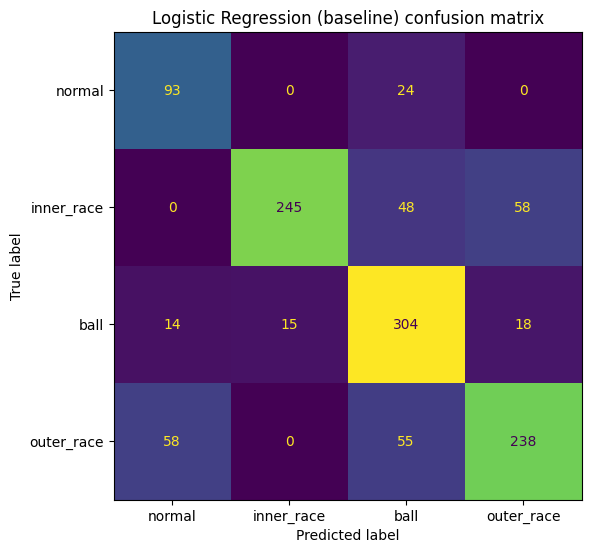

Random Forest (baseline) accuracy: 0.943590

              precision    recall  f1-score   support

        ball       0.85      0.99      0.91       351
  inner_race       0.98      0.95      0.96       351
      normal       1.00      1.00      1.00       117
  outer_race       1.00      0.88      0.94       351

    accuracy                           0.94      1170
   macro avg       0.96      0.95      0.95      1170
weighted avg       0.95      0.94      0.94      1170


[[346   5   0   0]
 [ 19 332   0   0]
 [  0   0 117   0]
 [ 41   1   0 309]]


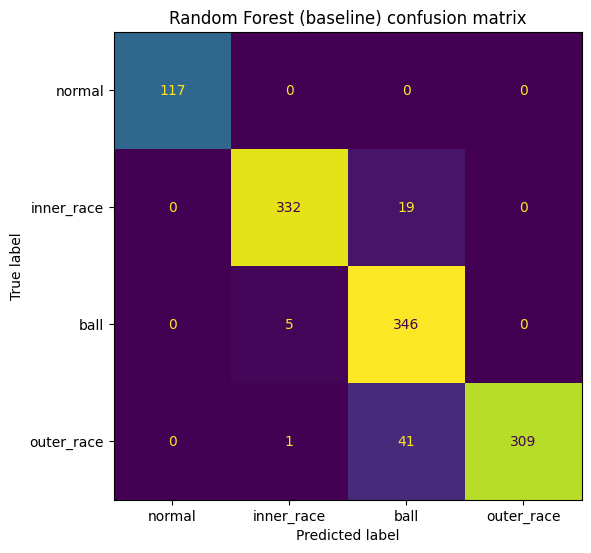

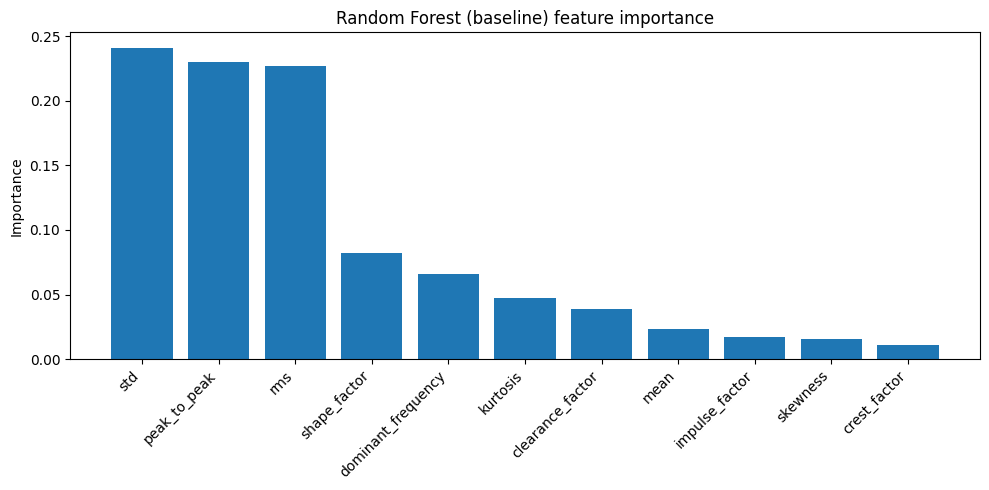

XGBoost (baseline) accuracy: 0.977778

              precision    recall  f1-score   support

        ball       0.94      0.99      0.97       351
  inner_race       0.99      0.99      0.99       351
      normal       0.99      1.00      1.00       117
  outer_race       1.00      0.95      0.97       351

    accuracy                           0.98      1170
   macro avg       0.98      0.98      0.98      1170
weighted avg       0.98      0.98      0.98      1170


[[349   1   1   0]
 [  5 346   0   0]
 [  0   0 117   0]
 [ 18   1   0 332]]


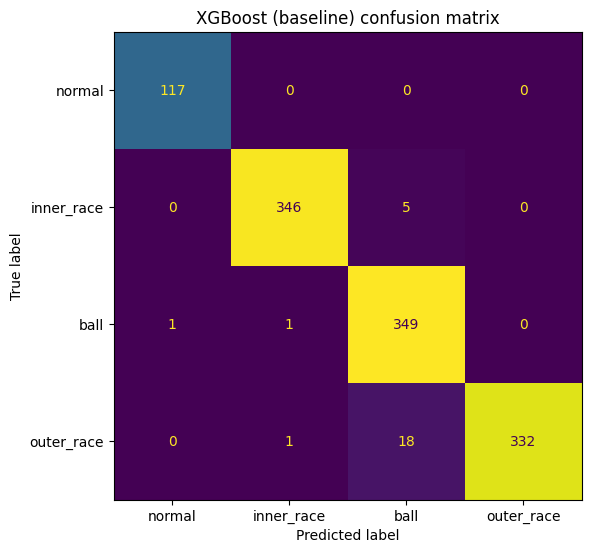

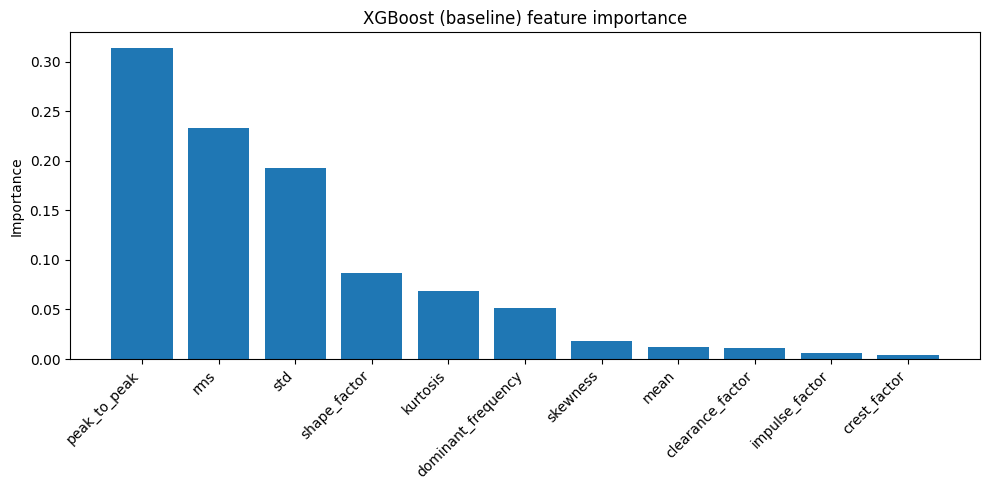

WindowsPath('C:/Users/Thomas/Desktop/bearing-condition-monitor/models/xgb_baseline_load012_test3.joblib')

In [35]:
logreg_baseline_model, y_pred_logreg_b, logreg_baseline_results = train_and_evaluate_model(
    model_name="Logistic Regression",
    feature_set_name="baseline",
    model=build_logistic_regression_model(),
    X_train=X_train_b,
    y_train=y_train_b,
    X_test=X_test_b,
    y_test=y_test_b,
    labels=labels,
    feature_columns=BASELINE_FEATURE_COLUMNS,
    figures_dir=figures_dir,
)

rf_baseline_model, y_pred_rf_b, rf_baseline_results = train_and_evaluate_model(
    model_name="Random Forest",
    feature_set_name="baseline",
    model=build_random_forest_model(),
    X_train=X_train_b,
    y_train=y_train_b,
    X_test=X_test_b,
    y_test=y_test_b,
    labels=labels,
    feature_columns=BASELINE_FEATURE_COLUMNS,
    figures_dir=figures_dir,
    save_feature_importance=True,
)

xgb_baseline_model, y_pred_xgb_b, xgb_baseline_results = train_and_evaluate_model(
    model_name="XGBoost",
    feature_set_name="baseline",
    model=build_xgboost_model(),
    X_train=X_train_b,
    y_train=y_train_b,
    X_test=X_test_b,
    y_test=y_test_b,
    labels=labels,
    feature_columns=BASELINE_FEATURE_COLUMNS,
    figures_dir=figures_dir,
    save_feature_importance=True,
    is_xgboost=True,
)

save_model(logreg_baseline_model, "logreg_baseline_load012_test3.joblib")
save_model(rf_baseline_model, "rf_baseline_load012_test3.joblib")
save_model(xgb_baseline_model, "xgb_baseline_load012_test3.joblib")


Logistic Regression (enhanced) accuracy: 0.985470

              precision    recall  f1-score   support

        ball       0.97      0.99      0.98       351
  inner_race       0.99      0.99      0.99       351
      normal       1.00      1.00      1.00       117
  outer_race       1.00      0.97      0.98       351

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170


[[349   2   0   0]
 [  3 348   0   0]
 [  0   0 117   0]
 [  9   3   0 339]]


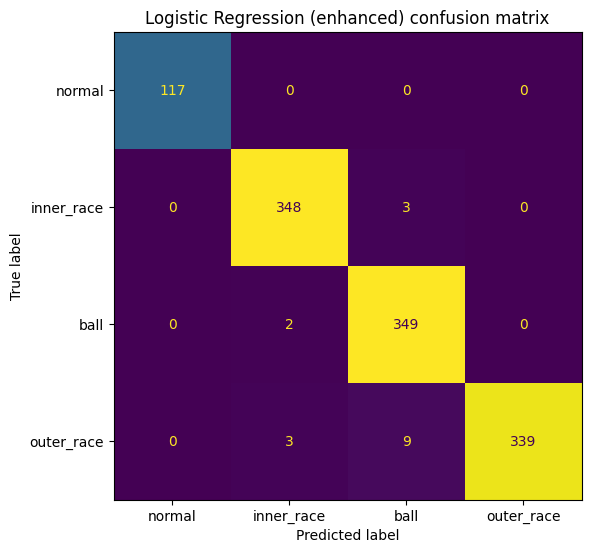

Random Forest (enhanced) accuracy: 0.965812

              precision    recall  f1-score   support

        ball       0.90      1.00      0.95       351
  inner_race       1.00      0.92      0.96       351
      normal       1.00      1.00      1.00       117
  outer_race       1.00      0.97      0.98       351

    accuracy                           0.97      1170
   macro avg       0.97      0.97      0.97      1170
weighted avg       0.97      0.97      0.97      1170


[[351   0   0   0]
 [ 28 323   0   0]
 [  0   0 117   0]
 [ 11   1   0 339]]


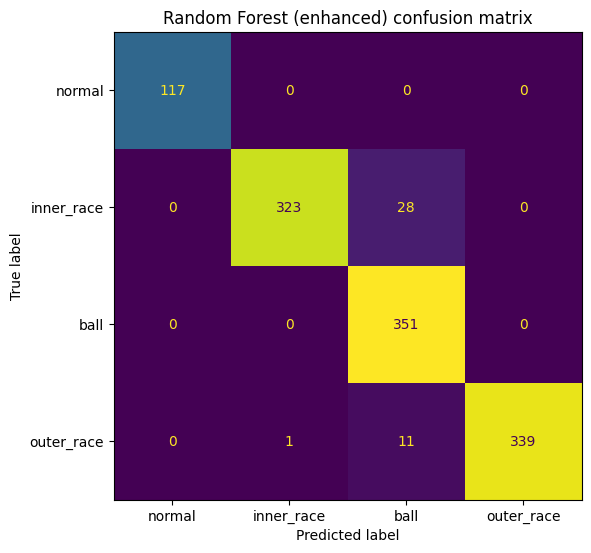

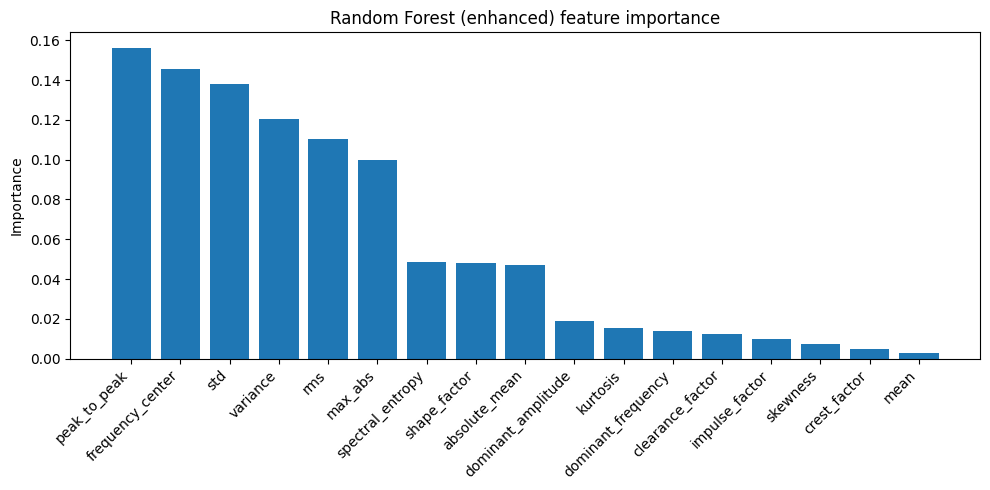

XGBoost (enhanced) accuracy: 0.989744

              precision    recall  f1-score   support

        ball       0.97      1.00      0.98       351
  inner_race       1.00      0.98      0.99       351
      normal       1.00      1.00      1.00       117
  outer_race       1.00      0.99      0.99       351

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170


[[351   0   0   0]
 [  7 344   0   0]
 [  0   0 117   0]
 [  4   1   0 346]]


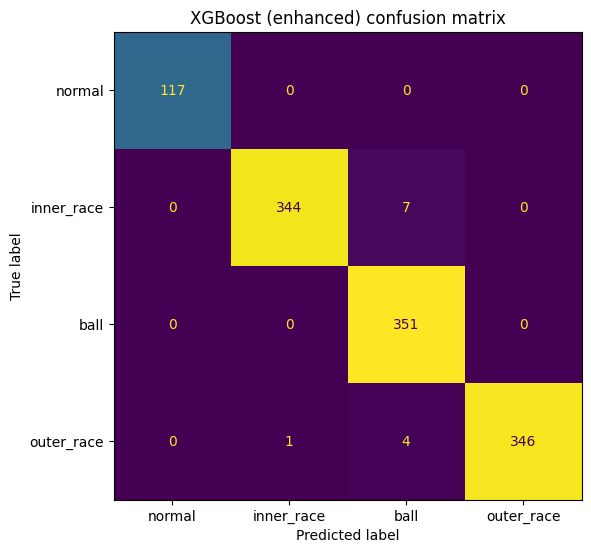

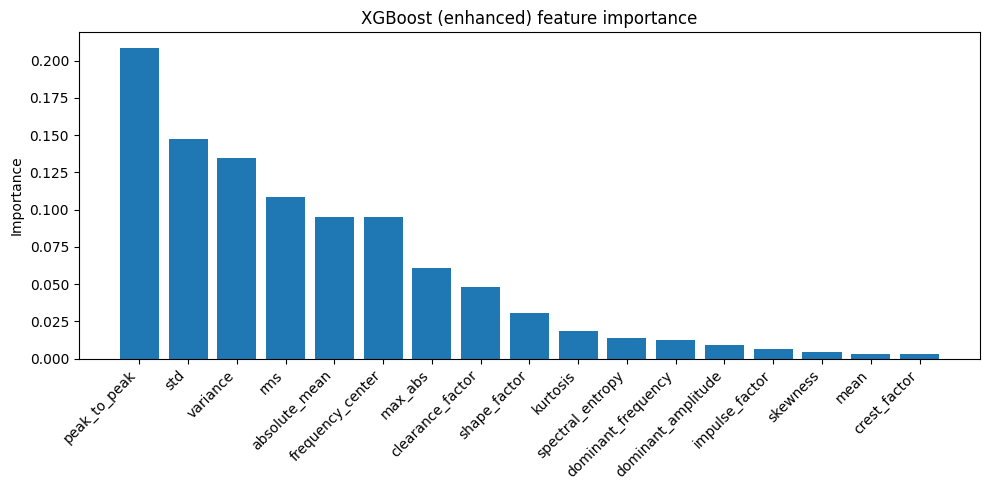

WindowsPath('C:/Users/Thomas/Desktop/bearing-condition-monitor/models/xgb_enhanced_load012_test3.joblib')

In [36]:
logreg_enhanced_model, y_pred_logreg_e, logreg_enhanced_results = train_and_evaluate_model(
    model_name="Logistic Regression",
    feature_set_name="enhanced",
    model=build_logistic_regression_model(),
    X_train=X_train_e,
    y_train=y_train_e,
    X_test=X_test_e,
    y_test=y_test_e,
    labels=labels,
    feature_columns=ENHANCED_FEATURE_COLUMNS,
    figures_dir=figures_dir,
)

rf_enhanced_model, y_pred_rf_e, rf_enhanced_results = train_and_evaluate_model(
    model_name="Random Forest",
    feature_set_name="enhanced",
    model=build_random_forest_model(),
    X_train=X_train_e,
    y_train=y_train_e,
    X_test=X_test_e,
    y_test=y_test_e,
    labels=labels,
    feature_columns=ENHANCED_FEATURE_COLUMNS,
    figures_dir=figures_dir,
    save_feature_importance=True,
)

xgb_enhanced_model, y_pred_xgb_e, xgb_enhanced_results = train_and_evaluate_model(
    model_name="XGBoost",
    feature_set_name="enhanced",
    model=build_xgboost_model(),
    X_train=X_train_e,
    y_train=y_train_e,
    X_test=X_test_e,
    y_test=y_test_e,
    labels=labels,
    feature_columns=ENHANCED_FEATURE_COLUMNS,
    figures_dir=figures_dir,
    save_feature_importance=True,
    is_xgboost=True,
)

save_model(logreg_enhanced_model, "logreg_enhanced_load012_test3.joblib")
save_model(rf_enhanced_model, "rf_enhanced_load012_test3.joblib")
save_model(xgb_enhanced_model, "xgb_enhanced_load012_test3.joblib")


In [37]:
held_out_results_df = comparison_df.copy()
held_out_results_df["split_type"] = "train_012_test_3"

output_path_held = processed_dir / "held_out_load3_results_v2.csv"
held_out_results_df.to_csv(output_path_held, index=False)

print(output_path_held)
print(output_path_held.exists())
held_out_results_df


c:\Users\Thomas\Desktop\bearing-condition-monitor\data\processed\held_out_load3_results_v2.csv
True


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1,split_type
0,Logistic Regression,baseline,3,3510,1170,11,0.752137,0.738705,train_012_test_3
1,Random Forest,baseline,3,3510,1170,11,0.943590,0.953553,train_012_test_3
2,XGBoost,baseline,3,3510,1170,11,0.977778,0.980833,train_012_test_3
3,Logistic Regression,enhanced,3,3510,1170,17,0.985470,0.987896,train_012_test_3
4,Random Forest,enhanced,3,3510,1170,17,0.965812,0.971754,train_012_test_3
5,XGBoost,enhanced,3,3510,1170,17,0.989744,0.991476,train_012_test_3


## Leave-one-load-out validation

In [38]:
def run_experiment_for_split(
    *,
    model_name,
    feature_set_name,
    test_load,
    X_train,
    X_test,
    y_train,
    y_test,
):
    if model_name == "Logistic Regression":
        model = build_logistic_regression_model()
        model = fit_model(model, X_train, y_train)
        y_pred = model.predict(X_test)

    elif model_name == "Random Forest":
        model = build_random_forest_model()
        model = fit_model(model, X_train, y_train)
        y_pred = model.predict(X_test)

    elif model_name == "XGBoost":
        model = build_xgboost_model()
        model, label_encoder = fit_xgboost_model(model, X_train, y_train)
        y_pred = predict_xgboost(model, label_encoder, X_test)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    results = evaluate_predictions(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "test_load": test_load,
        "n_train_windows": len(y_train),
        "n_test_windows": len(y_test),
        "n_features": X_train.shape[1],
        "accuracy": results["accuracy"],
        "macro_f1": macro_f1,
    }


In [39]:
loo_rows = []

feature_set_configs = [
    ("baseline", balanced_feature_table_baseline, BASELINE_FEATURE_COLUMNS),
    ("enhanced", balanced_feature_table_enhanced, ENHANCED_FEATURE_COLUMNS),
]

model_names = ["Logistic Regression", "Random Forest", "XGBoost"]

for feature_set_name, df_model, feature_columns in feature_set_configs:
    for test_load in [0, 1, 2, 3]:
        train_loads = [load for load in [0, 1, 2, 3] if load != test_load]

        train_df, test_df, X_train, X_test, y_train, y_test = split_by_load(
            df=df_model,
            train_loads=train_loads,
            test_loads=[test_load],
            feature_columns=feature_columns,
        )

        for model_name in model_names:
            loo_rows.append(
                run_experiment_for_split(
                    model_name=model_name,
                    feature_set_name=feature_set_name,
                    test_load=test_load,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test,
                )
            )

loo_results_df = pd.DataFrame(loo_rows).sort_values(
    ["feature_set", "test_load", "model"]
).reset_index(drop=True)

loo_results_df


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1
0,Logistic Regression,baseline,0,3510,1170,11,0.335043,0.355376
1,Random Forest,baseline,0,3510,1170,11,0.885470,0.900841
2,XGBoost,baseline,0,3510,1170,11,0.885470,0.861848
3,Logistic Regression,baseline,1,3510,1170,11,0.882906,0.901011
4,Random Forest,baseline,1,3510,1170,11,0.995726,0.996439
5,XGBoost,baseline,1,3510,1170,11,0.995726,0.996439
6,Logistic Regression,baseline,2,3510,1170,11,0.889744,0.906387
7,Random Forest,baseline,2,3510,1170,11,0.994017,0.995014
8,XGBoost,baseline,2,3510,1170,11,0.996581,0.997151
9,Logistic Regression,baseline,3,3510,1170,11,0.752137,0.738705


In [40]:
loo_results_df.shape, loo_results_df.groupby(["feature_set", "model"]).size()


((24, 8),
 feature_set  model              
 baseline     Logistic Regression    4
              Random Forest          4
              XGBoost                4
 enhanced     Logistic Regression    4
              Random Forest          4
              XGBoost                4
 dtype: int64)

In [41]:
output_path_loo = processed_dir / "leave_one_load_out_results_v2.csv"
loo_results_df.to_csv(output_path_loo, index=False)

print(output_path_loo)
print(output_path_loo.exists())


c:\Users\Thomas\Desktop\bearing-condition-monitor\data\processed\leave_one_load_out_results_v2.csv
True


In [42]:
loo_summary_df = (
    loo_results_df
    .groupby(["feature_set", "model"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        min_accuracy=("accuracy", "min"),
        mean_macro_f1=("macro_f1", "mean"),
        min_macro_f1=("macro_f1", "min"),
    )
    .sort_values(["mean_macro_f1", "mean_accuracy"], ascending=False)
    .reset_index(drop=True)
)

loo_summary_df


,feature_set,model,mean_accuracy,min_accuracy,mean_macro_f1,min_macro_f1
0,enhanced,XGBoost,0.986538,0.962393,0.988772,0.968607
1,enhanced,Random Forest,0.986325,0.965812,0.988131,0.971754
2,baseline,Random Forest,0.954701,0.885470,0.961462,0.900841
3,baseline,XGBoost,0.963889,0.885470,0.959068,0.861848
4,enhanced,Logistic Regression,0.875641,0.536752,0.873702,0.523370
5,baseline,Logistic Regression,0.714957,0.335043,0.725370,0.355376


In [43]:
output_path_loo_summary = processed_dir / "leave_one_load_out_summary_v2.csv"
loo_summary_df.to_csv(output_path_loo_summary, index=False)

print(output_path_loo_summary)
print(output_path_loo_summary.exists())


c:\Users\Thomas\Desktop\bearing-condition-monitor\data\processed\leave_one_load_out_summary_v2.csv
True


In [44]:
loo_results_df.sort_values(
    ["macro_f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)


,model,feature_set,test_load,n_train_windows,n_test_windows,n_features,accuracy,macro_f1
0,Random Forest,enhanced,2,3510,1170,17,1.000000,1.000000
1,XGBoost,enhanced,2,3510,1170,17,0.999145,0.999288
2,Logistic Regression,enhanced,2,3510,1170,17,0.997436,0.997862
3,XGBoost,baseline,2,3510,1170,11,0.996581,0.997151
4,Random Forest,enhanced,1,3510,1170,17,0.996581,0.997147
5,Random Forest,baseline,1,3510,1170,11,0.995726,0.996439
6,XGBoost,baseline,1,3510,1170,11,0.995726,0.996439
7,XGBoost,enhanced,1,3510,1170,17,0.994872,0.995718
8,Random Forest,baseline,2,3510,1170,11,0.994017,0.995014
9,XGBoost,enhanced,3,3510,1170,17,0.989744,0.991476


## Visual summary plots

In [45]:
mean_accuracy_df = (
    loo_results_df
    .pivot_table(
        index="feature_set",
        columns="model",
        values="accuracy",
        aggfunc="mean",
    )
)

mean_accuracy_df


model,Logistic Regression,Random Forest,XGBoost
feature_set,,,
baseline,0.714957,0.954701,0.963889
enhanced,0.875641,0.986325,0.986538


<Figure size 900x500 with 0 Axes>

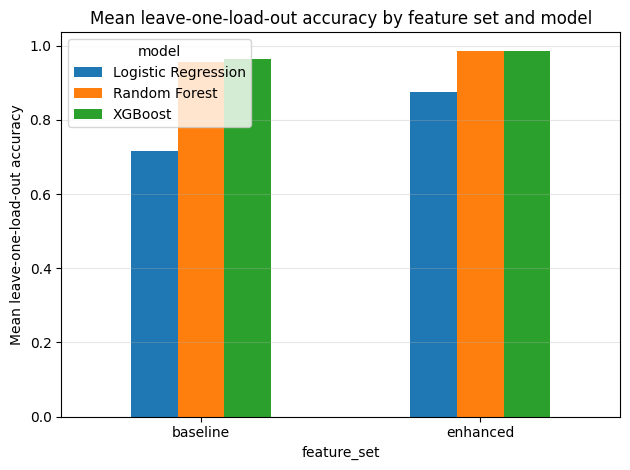

In [46]:
plt.figure(figsize=(9, 5))
mean_accuracy_df.plot(kind="bar", rot=0)
plt.ylabel("Mean leave-one-load-out accuracy")
plt.title("Mean leave-one-load-out accuracy by feature set and model")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


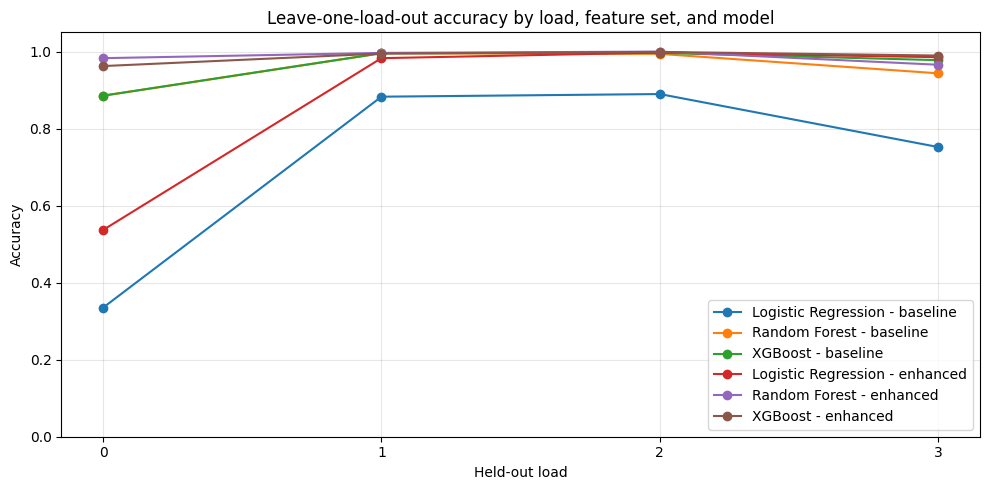

In [47]:
plt.figure(figsize=(10, 5))

for (feature_set_name, model_name), group in loo_results_df.groupby(["feature_set", "model"]):
    plt.plot(
        group["test_load"],
        group["accuracy"],
        marker="o",
        label=f"{model_name} - {feature_set_name}",
    )

plt.xlabel("Held-out load")
plt.ylabel("Accuracy")
plt.title("Leave-one-load-out accuracy by load, feature set, and model")
plt.xticks([0, 1, 2, 3])
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
